# Computing energy histogram and specific test images

In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from covariance_generation import *

from networks.conditioning import *

import lpips

seed = 20
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load model

In [2]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict['size_network'] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module
    # === APPLY EMA HERE ===
    if getattr(ctx, "ema_loaded_from_checkpoint", False):
        ctx.ema.apply_shadow(ctx.network)
        
    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

def get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dis):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)

# args = load_args("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "best")
args = load_args("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = "best")
# args = load_args("multigpu/inpainting_celeba/energy_song_autoregressive_Celeba", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
step = "last"
ctxs = {
            "Energy-Dual": load_exp("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = step),
        }

default_ctx = ctxs["Energy-Dual"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 16
H = 64
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=8, seed=20
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")


loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores

False
[EMA LOAD] 'ema' NOT in checkpoint (use_ema=True)
multigpu/all_together/energy_song_dual_truncatedFreq_celeba: retrieved model at step 400000
Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth


## Celeba

In [ ]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=120, num_workers=8, seed=10
)

n_files = 400
path = "samples/imagenet_21_0.06_PC_adaptive" #Celeba_45_0.06_PC_adaptive_pixel"
batch_size = 120
logp_true = torch.zeros(n_files * batch_size)
likelihood_x_true = torch.zeros(n_files * batch_size)
imgs_true = torch.zeros(n_files * batch_size, 3, 64, 64)

sigma_box = 1e-5 #1e-4
sigma_clean_init = 1e-3 #1e-3
domain = 'pixel' #'freq' #
inp_mask_type = "box"
box_size = 21 #45 #21 #13
img_size = H

def compute_entropy(x_input, covariance, model, sigma):
    noise_level = NoiseLevel(variance=sigma**2)
    input = ModelInput(noisy=x_input.cuda(), noise_level=noise_level, covariance=covariance)
    model_output = model.forward(input, create_graph = False)
    # energy_values[bs*batch_size:bs*batch_size+batch_size] = model_output.energy # log p(x_0)
    # c = lambda e: LogTensor(e, CHW).to(base="dBs", sign="logp", per_dimension=True)
    # logp = c(model_output.energy)
    # entropy_x[bs*batch_size:bs*batch_size+batch_size] = -model_output.energy#logp

    return -model_output.energy

for bs, images in enumerate(test_dataloader):
    # THIS IS FOR IMAGENET
    # covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-2**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
    # # torch.randn_like(images[0]).
    # noise = torch.randn((20, 3, 64, 64))
    # noise = apply_power_to_list_covariances(covariance, noise.cuda() , p =0.5)
    # x_true = images[0].cuda() + noise
    ##
    x_true = images[0] #torch.clamp(images[0] + sigma_box * torch.randn_like(images[0]), 0, 1)
    # mask = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
    # saved_outputs = torch.load(f"{path}/samples_posterior_{bs}.pt")
    # y_ours = saved_outputs['y'].detach()# + 1e-3 * torch.randn_like(saved_outputs['y'])
    ##
    # plt.figure(1)
    # plt.imshow(y_ours[0].cpu().permute(1,2,0).numpy())
    # plt.show()
    # plt.figure(2)
    # plt.imshow(x_true[0].permute(1,2,0).numpy())
    # plt.show()
    with torch.no_grad():

        # Compute entropy of our model #
        # covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=0**2, device=device, var_clean = 0**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=sigma_box**2, device=device, var_clean = sigma_box**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        logp_true[bs*batch_size:bs*batch_size+batch_size] = compute_entropy(x_true.cuda(), covariance, ctxs["Energy-Dual"].model, sigma = 0)        

        # covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=box_size, var_box=1e-3**2, device=device, var_clean = 1e-3**2, half_box_size = box_size, inp_mask_type=inp_mask_type)] * batch_size
        # likelihood_true = apply_power_to_list_covariances(covariance, y_ours - apply_power_to_list_covariances(mask, x_true.cuda(), p =1) , p=-0.5) / 2
        # likelihood_x_true[bs*batch_size:bs*batch_size+batch_size] = -torch.sum(likelihood_true ** 2, dim=(-1, -2, -3)).to('cpu')# energy_post[bs*batch_size:bs*batch_size+batch_size] = e - energy_values[bs*batch_size:bs*batch_size+batch_size] #logp + logp

        # imgs_true[bs*batch_size:bs*batch_size+batch_size] = x_true

        # mse_batch = torch.mean((imgs_true[bs*batch_size:bs*batch_size+batch_size] - samples[0:batch_size])**2, dim=(-1, -2, -3)).sum() 
        # for ii in range(batch_size):
        #     lpips_batch += loss_fn_alex(images[0][ii+idx_img:ii+idx_img+1,:,:,:].cuda(),  samples[ii:ii+1].cuda())
        
        # mse += mse_batch.item()
        # lpips_ += lpips_batch.item()

    print(bs)
    if bs % n_files == 0 and bs > 0:
    # if bs == 0:
        break

tensor([11619.9941], device='cuda:0', grad_fn=<NegBackward0>)
tensor([-38300.7539], device='cuda:0', grad_fn=<NegBackward0>)


In [151]:
p_xy = logp_true.cuda() + constants.cpu()
log10p_xy = (10.0 / np.log(10)) * p_xy
log10p_xy = log10p_xy/ CHW

tensor([17.5968, 17.6346, 18.0964, 18.4831, 18.5277, 18.5314, 18.5572, 18.7074,
        18.7982, 18.8930, 19.1233, 19.2098, 19.3459, 19.4444, 19.5388, 19.5515,
        19.7242, 19.8433, 19.8873, 19.9900, 20.1993, 20.2573, 20.2917, 20.3423,
        20.3742, 20.5238, 20.5760, 20.6115, 20.6258, 20.6513, 20.8883, 20.8983,
        20.9017, 20.9056, 20.9654, 20.9713, 20.9884, 20.9961, 21.1827, 21.2755,
        21.3316, 21.3406, 21.4858, 21.5214, 21.5538, 21.5832, 21.6008, 21.7093,
        21.7944, 21.8809, 21.9124, 21.9719, 22.0605, 22.1023, 22.1047, 22.2902,
        22.3050, 22.3136, 22.4874, 22.4980, 22.5189, 22.5905, 22.6087, 22.6977,
        22.7156, 22.7704, 22.8041, 22.8801, 22.9218, 22.9261, 23.0062, 23.0642,
        23.1190, 23.1393, 23.1458, 23.1954, 23.2532, 23.2929, 23.4027, 23.4732,
        23.5577, 23.7233, 23.9664, 24.0856, 24.1071, 24.2291, 24.2933, 24.3042,
        24.4271, 24.4731, 24.5695, 24.5793, 24.5872, 24.6228, 24.9608, 25.0269,
        25.4013, 25.5397, 26.1364, 26.39

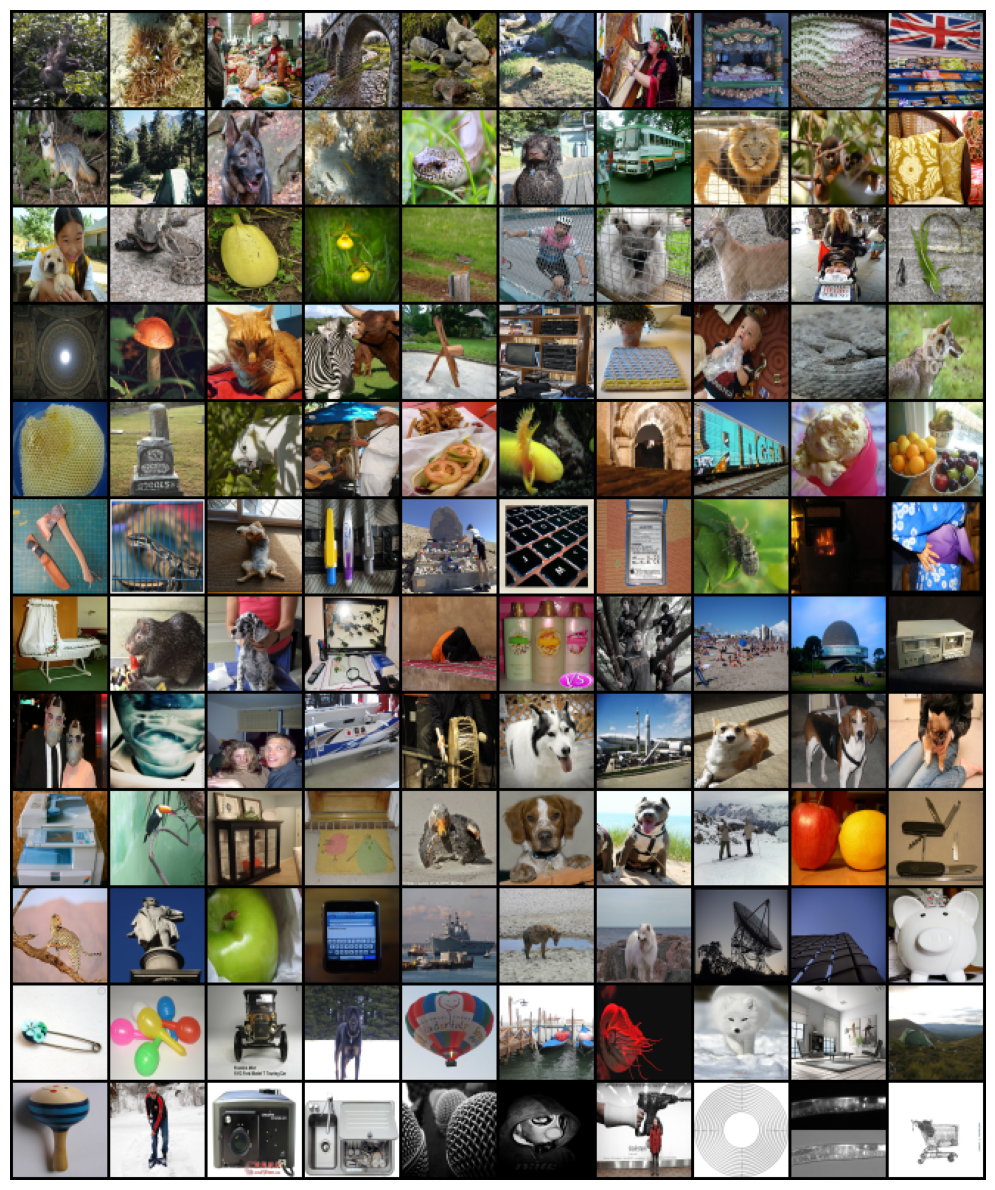

In [153]:
val, idxs = log10p_xy.sort(descending = False) # log p
print(val)
grid = torchvision.utils.make_grid(images[0][idxs.cpu()].cpu(), nrow=10, padding=2)
grid_energy = grid.permute(1, 2, 0).numpy()


fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(grid_energy)
ax.axis("off")

plt.tight_layout()
# plt.show()
# plt.tight_layout()
plt.savefig("images_sorted_imagenet_rebuttal.pdf")


scipy.stats.gumbel_r.fit -> loc = 21.2979, scale = 2.7755


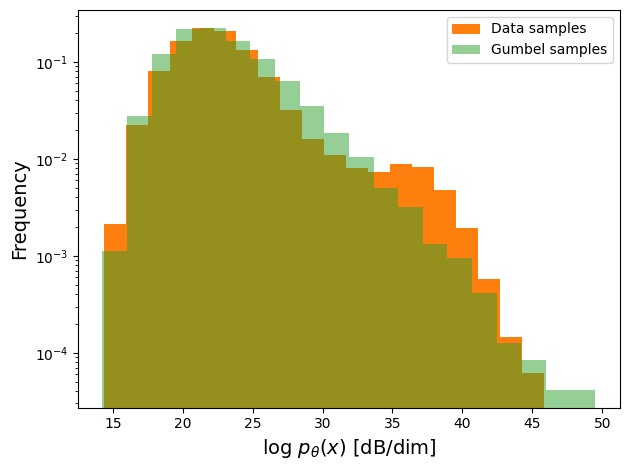

In [165]:
import scipy.stats as sts
from scipy import optimize

p_xy = logp_true.cuda() + constants.cpu()
log10p_xy = (10.0 / np.log(10)) * p_xy
bins = 20
# plt.figure(1)
# plt.hist((log10p_xy / CHW).cpu().detach(), bins=bins, 
#          weights=np.ones(len(p_xy.detach().cpu().numpy())) / len(p_xy.detach().cpu().numpy()), 
#          color='tab:blue', label='Data')

# # Fit Gumbel distribution and plot PDF curve
# data = (log10p_xy / CHW).cpu().detach().numpy()
# loc, scale = sts.gumbel_r.fit(data)
# x = np.linspace(data.min(), data.max(), 1000)
# pdf = gumbel_r.pdf(x, loc=loc, scale=scale)

# # Scale PDF to match histogram (normalized by bin width)
# bin_width = bins[1] - bins[0] if hasattr(bins, '__len__') else (data.max() - data.min()) / bins
# plt.plot(x, pdf * bin_width, color='red', linewidth=2, label='Gumbel fit')

# plt.legend()
# plt.yscale('log')
# # scipy's gumbel_r.fit returns (loc, scale) MLEs by default (actually order: loc, scale)
mle_loc, mle_scale = sts.gumbel_r.fit((log10p_xy / CHW).detach().cpu().numpy())
print("scipy.stats.gumbel_r.fit -> loc = {:.4f}, scale = {:.4f}".format(mle_loc, mle_scale))
# Define Gumbel distribution parameters
mu = mle_loc # Location parameter
beta = mle_scale # Scale parameter

# Generate random samples from a Gumbel distribution
num_samples = log10p_xy.shape
s = np.random.gumbel(loc=mu, scale=beta, size=num_samples)

# Plot the histogram of the samples
plt.figure(1)
plt.hist((log10p_xy / CHW).cpu().detach(), bins = bins, weights=np.ones(len(p_xy.detach().cpu().numpy())) / len(p_xy.detach().cpu().numpy()), color = 'tab:orange', label = 'Data samples') 
plt.hist(s, bins=bins, alpha=0.5, weights=np.ones(len(s)) / len(s), color='tab:green', label='Gumbel samples')
plt.legend()
plt.yscale('log')

plt.xlabel(r"log $p_{\theta}(x)$ [dB/dim]", fontsize=14)
plt.ylabel(r"Frequency", fontsize=14)
plt.tight_layout()
plt.savefig('gumbel_fit2.pdf')

# p_xy = logp_true.cuda() + constants.cpu()
# log10p_xy = (10.0 / np.log(10)) * p_xy
# bins = 30

# # Use log-spaced bins for log x-axis
# values = (log10p_xy / CHW).cpu().detach().numpy()
# log_bins = np.logspace(np.log10(values.min()), np.log10(values.max()), bins)

# fig, ax = plt.subplots()
# ax.hist(values, bins=log_bins, 
#         weights=np.ones(len(values)) / len(values), 
#         color='tab:orange')

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel('log10 p(x,y) / CHW')
# ax.set_ylabel('Frequency (log scale)')
# plt.show()

In [6]:
def compute_energy(x_input, covariance, model, sigma):
    noise_level = NoiseLevel(variance=sigma**2)
    input = ModelInput(noisy=x_input.cuda(), noise_level=noise_level, covariance=covariance)
    model_output = model.forward(input, create_graph = False)
    # energy_values[bs*batch_size:bs*batch_size+batch_size] = model_output.energy # log p(x_0)
    # c = lambda e: LogTensor(e, CHW).to(base="dBs", sign="logp", per_dimension=True)
    # logp = c(model_output.energy)
    # entropy_x[bs*batch_size:bs*batch_size+batch_size] = -model_output.energy#logp

    return model_output.energy


train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=20, num_workers=8, seed=20
)


img_size = H
energy_t = 0
t = 1e3
for batch_idx, images in enumerate(test_dataloader):

    y = images[0] + np.sqrt(t) * torch.randn_like(images[0])
    y = torch.clamp(y, 0, 1)
    batch_size = y.shape[0]
    covariance = [spatial_corr_covariance_testing(spatial_size=img_size, box_size=45, var_box=t, device=device, var_clean = t, half_box_size = 45, inp_mask_type="box")] * batch_size

    with torch.no_grad():
        energy_t = energy_t + compute_energy(y, covariance, ctxs["Energy-Dual"].model, sigma = 1e3).sum()

    if batch_idx % 50 == 0 and batch_idx > 0:
        break
print((batch_idx + 1) * batch_size, batch_idx, batch_size)
energy_t_mean = energy_t / ((batch_idx + 1) * batch_size) 
constants = (CHW) /2 * np.log(2 * np.pi * np.e * t) - energy_t_mean

print(constants)

Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
1020 50 20
tensor(59882.5938, device='cuda:0')
